# ADAUSDT non-overlapping future return opportunities

??????? ????????? ??????? ????? ??????????? ???????? ???????????? ? ???? ??? ?????????? `1..60` ????? ? ??????? `0.5%`, `1.0%`, `1.5%`.

?????: ??????? `targets/future_returns` ?????? ????????? ???????? ???? ?????????? ??? ??? `0`, ? ?? ??? `NaN`. ??????? ?????????? ??????? future window ????? ????????????????? ?? ?????????? ???????: ?????????? ???????????? ?????? ???? ??????? timestamp `open_time + horizon` ????????????? ?????????? ? ????? dataset.

In [1]:
import io
import os
import re

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib.ticker import MultipleLocator

BUCKET = "binance-data-downloader"
TARGETS_PREFIX = "targets"
TARGET_DATASET_NAME = "future_returns"
SYMBOL = "ADAUSDT"
INTERVAL = "1m"
HORIZONS = list(range(1, 61))
THRESHOLDS = [0.005, 0.01, 0.015]
THRESHOLD_LABELS = {0.005: "0.5%", 0.01: "1.0%", 0.015: "1.5%"}
RETURN_COLUMNS = [f"return_{h}m" for h in HORIZONS]


def make_s3_client():
    load_dotenv()
    return boto3.client(
        "s3",
        endpoint_url=os.getenv("YC_ENDPOINT"),
        region_name=os.getenv("YC_REGION"),
        aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
    )

In [2]:
def list_future_return_keys(symbol: str = SYMBOL, bucket: str = BUCKET, targets_prefix: str = TARGETS_PREFIX, dataset_name: str = TARGET_DATASET_NAME, interval: str = INTERVAL, s3_client=None) -> list[str]:
    s3 = s3_client or make_s3_client()
    prefix = f"{targets_prefix.strip('/')}/{dataset_name}/symbol={symbol}/interval={interval}/"
    pattern = re.compile(r"/date=(\d{4}-\d{2}-\d{2})/data\.parquet$")
    keys = []
    for page in s3.get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            if pattern.search('/' + obj["Key"]):
                keys.append(obj["Key"])
    return sorted(keys)


def read_future_returns_dataset(symbol: str = SYMBOL, bucket: str = BUCKET, targets_prefix: str = TARGETS_PREFIX, dataset_name: str = TARGET_DATASET_NAME, interval: str = INTERVAL, s3_client=None) -> tuple[pd.DataFrame, int]:
    s3 = s3_client or make_s3_client()
    keys = list_future_return_keys(symbol, bucket, targets_prefix, dataset_name, interval, s3)
    if not keys:
        raise FileNotFoundError("No future_returns parquet files found")
    frames = []
    expected_columns = ["open_time", *RETURN_COLUMNS]
    for key in keys:
        obj = s3.get_object(Bucket=bucket, Key=key)
        frames.append(pd.read_parquet(io.BytesIO(obj["Body"].read()), columns=expected_columns))
    df = pd.concat(frames, ignore_index=True).sort_values("open_time").reset_index(drop=True)
    return df, len(keys)

In [3]:
def build_valid_future_return_series(returns_df: pd.DataFrame, horizon: int) -> pd.Series:
    column = f"return_{horizon}m"
    open_times = returns_df["open_time"].astype("int64")
    target_times = open_times + horizon * 60_000
    existing_open_times = pd.Index(open_times)
    valid_target_exists = target_times.isin(existing_open_times)
    values = pd.to_numeric(returns_df[column], errors="coerce").copy()
    values.loc[~valid_target_exists] = np.nan
    return values


def count_non_overlapping_events(series: pd.Series, horizon: int, threshold: float) -> int:
    values = series.to_numpy(dtype="float64")
    events = 0
    t = 0
    while t < len(values):
        value = values[t]
        if not np.isnan(value) and abs(value) >= threshold:
            events += 1
            t += horizon
        else:
            t += 1
    return events


def build_opportunity_statistics(returns_df: pd.DataFrame, number_of_calendar_days: int, horizons: list[int] = HORIZONS, thresholds: list[float] = THRESHOLDS) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        for horizon in horizons:
            valid_series = build_valid_future_return_series(returns_df, horizon)
            total_events = count_non_overlapping_events(valid_series, horizon, threshold)
            rows.append({
                "horizon": horizon,
                "threshold": threshold,
                "total_events": total_events,
                "events_per_day": total_events / number_of_calendar_days,
            })
    return pd.DataFrame(rows).sort_values(["threshold", "horizon"]).reset_index(drop=True)


def plot_opportunity_statistics(opportunity_df: pd.DataFrame, save_path: str | None = None):
    fig, ax = plt.subplots(figsize=(14, 8))
    for threshold in THRESHOLDS:
        subset = opportunity_df[opportunity_df["threshold"] == threshold]
        ax.plot(subset["horizon"], subset["events_per_day"], label=THRESHOLD_LABELS[threshold])
    ax.set_title("??????? ????? ??????????? ???????? ???????????? ADAUSDT ? ????")
    ax.set_xlabel("????????, ?????")
    ax.set_ylabel("??????? ????? ???????????????? ???????????? ? ????")
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend(title="?????")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig, ax

In [4]:
# ???????? ?????? ? ?????? ???????? ??????????.
s3 = make_s3_client()
future_returns_df, number_of_calendar_days = read_future_returns_dataset(s3_client=s3)
opportunity_statistics = build_opportunity_statistics(future_returns_df, number_of_calendar_days)

print("calendar days:", number_of_calendar_days)
display(opportunity_statistics.head())
display(opportunity_statistics.tail())

calendar days: 2193


,horizon,threshold,total_events,events_per_day
0,1,0.005,39603,18.058824
1,2,0.005,70287,32.050616
2,3,0.005,85809,39.128591
3,4,0.005,93940,42.836297
4,5,0.005,98579,44.951664


,horizon,threshold,total_events,events_per_day
175,56,0.015,14615,6.664387
176,57,0.015,14564,6.641131
177,58,0.015,14528,6.624715
178,59,0.015,14515,6.618787
179,60,0.015,14532,6.626539


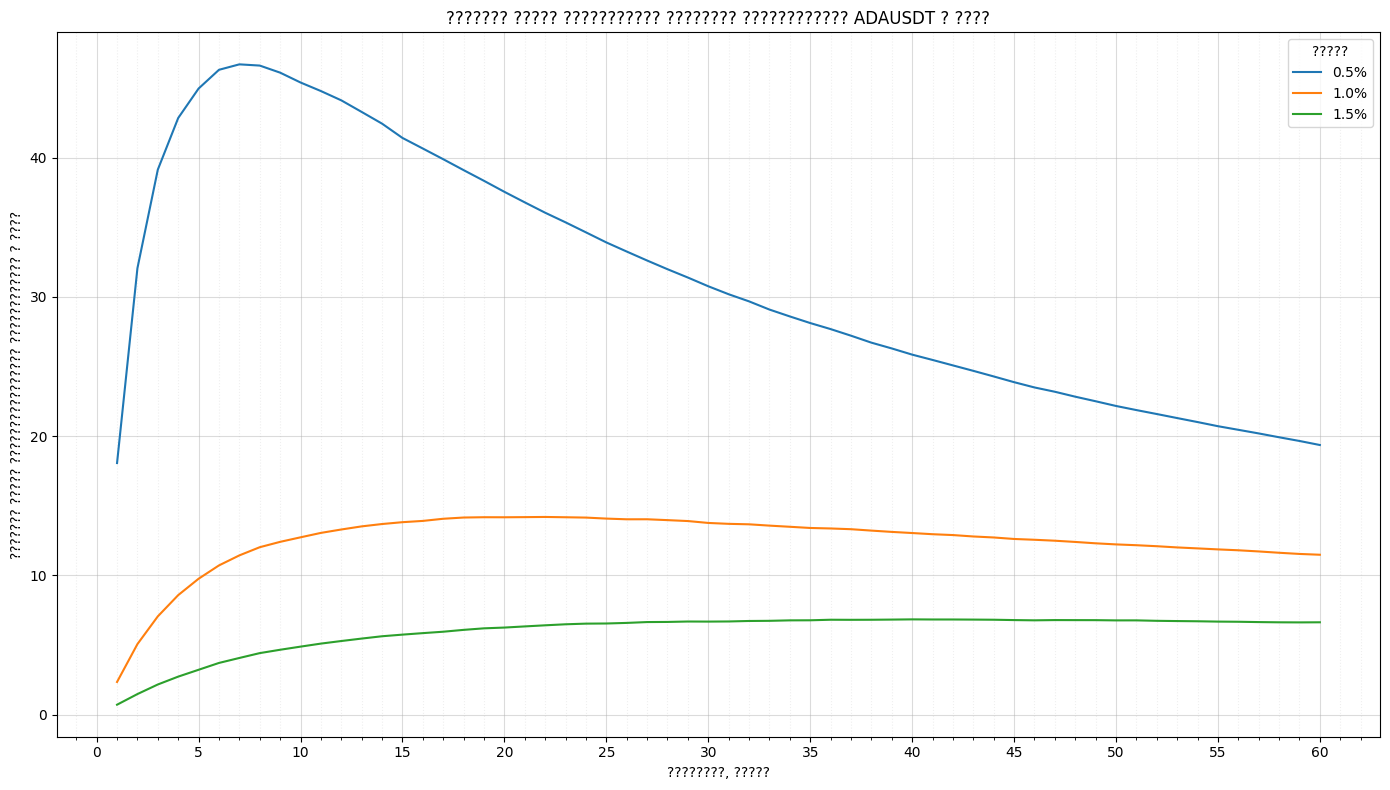

In [5]:
# ???? ????? ??????.
fig, ax = plot_opportunity_statistics(opportunity_statistics)
plt.show()

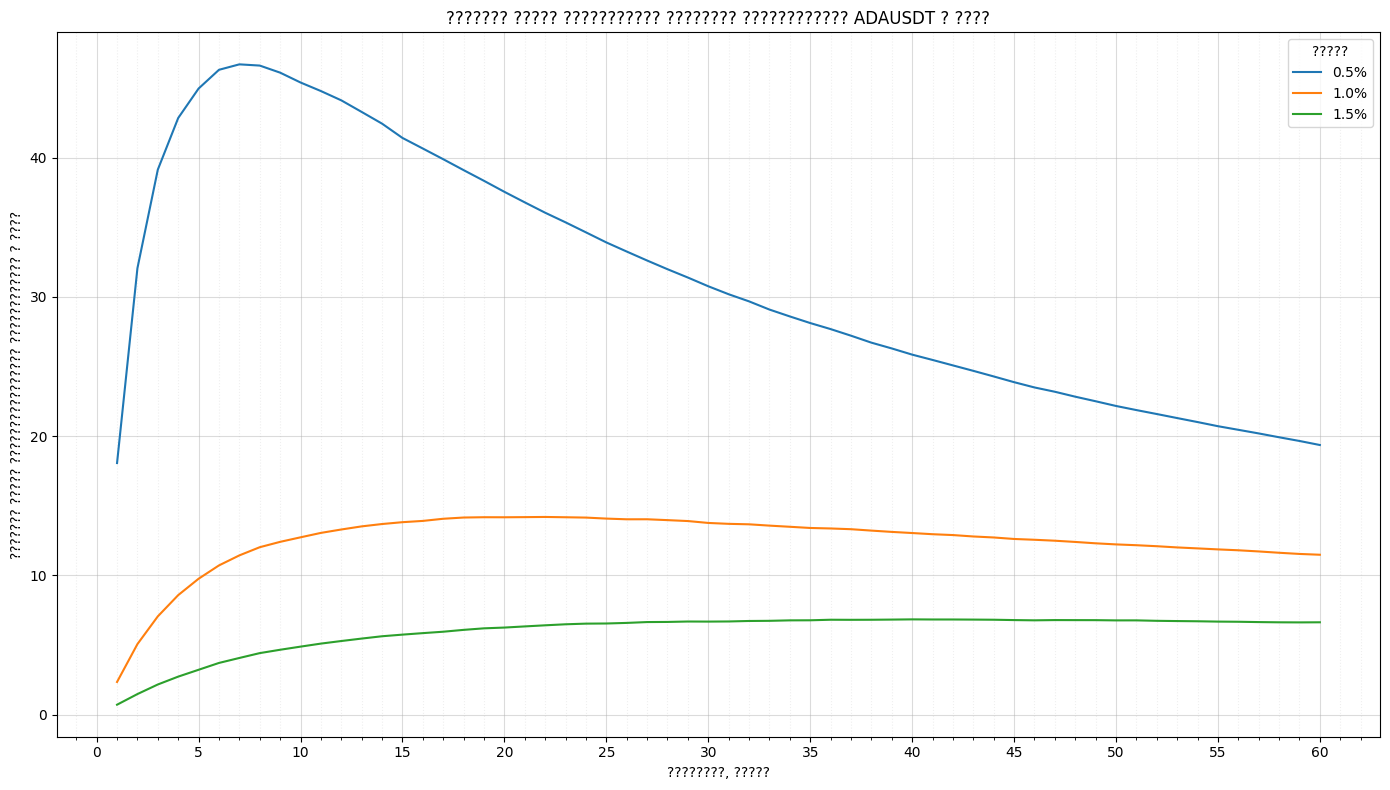

In [6]:
# ?????????? ???????????.
opportunity_statistics.to_parquet("adausdt_non_overlapping_opportunities.parquet", index=False)
opportunity_statistics.to_csv("adausdt_non_overlapping_opportunities.csv", index=False)
fig, ax = plot_opportunity_statistics(
    opportunity_statistics,
    save_path="adausdt_non_overlapping_opportunities.png",
)

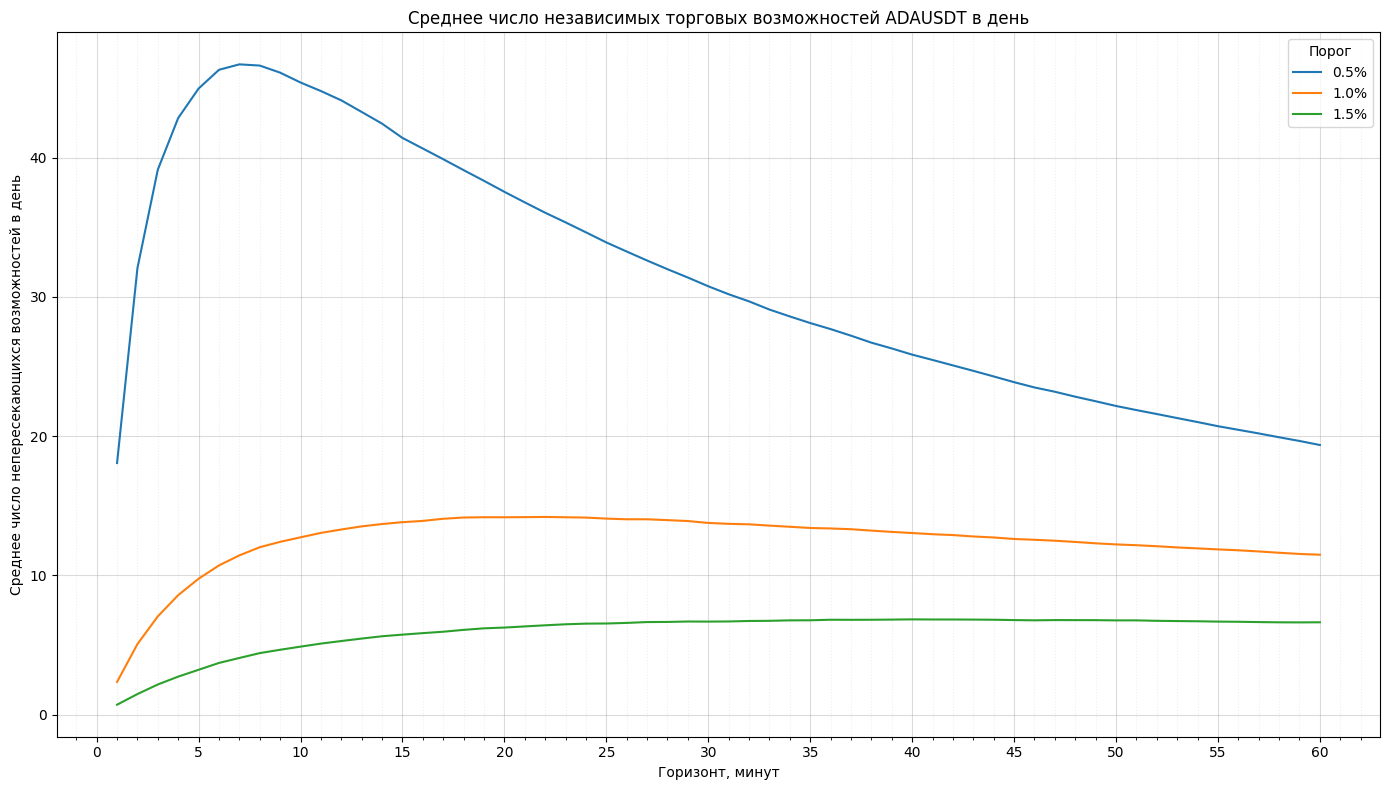

In [7]:
def plot_opportunity_statistics(opportunity_df: pd.DataFrame, save_path: str | None = None):
    fig, ax = plt.subplots(figsize=(14, 8))

    threshold_labels = {
        0.005: "0.5%",
        0.01: "1.0%",
        0.015: "1.5%",
    }

    for threshold in THRESHOLDS:
        subset = opportunity_df[opportunity_df["threshold"] == threshold]
        ax.plot(
            subset["horizon"],
            subset["events_per_day"],
            label=threshold_labels[threshold],
        )

    ax.set_title("Среднее число независимых торговых возможностей ADAUSDT в день")
    ax.set_xlabel("Горизонт, минут")
    ax.set_ylabel("Среднее число непересекающихся возможностей в день")

    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(True, which="minor", alpha=0.2, linestyle=":")
    ax.legend(title="Порог")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, ax


fig, ax = plot_opportunity_statistics(opportunity_statistics)
plt.show()

,year,horizon,threshold,total_events,events_per_day
0,2020,1,0.005,7227,21.573134
1,2020,2,0.005,12396,37.002985
2,2020,3,0.005,15207,45.394030
3,2020,4,0.005,16788,50.113433
4,2020,5,0.005,17523,52.307463


,year,horizon,threshold,total_events,events_per_day
1255,2026,56,0.015,131,4.09375
1256,2026,57,0.015,128,4.00000
1257,2026,58,0.015,127,3.96875
1258,2026,59,0.015,134,4.18750
1259,2026,60,0.015,130,4.06250


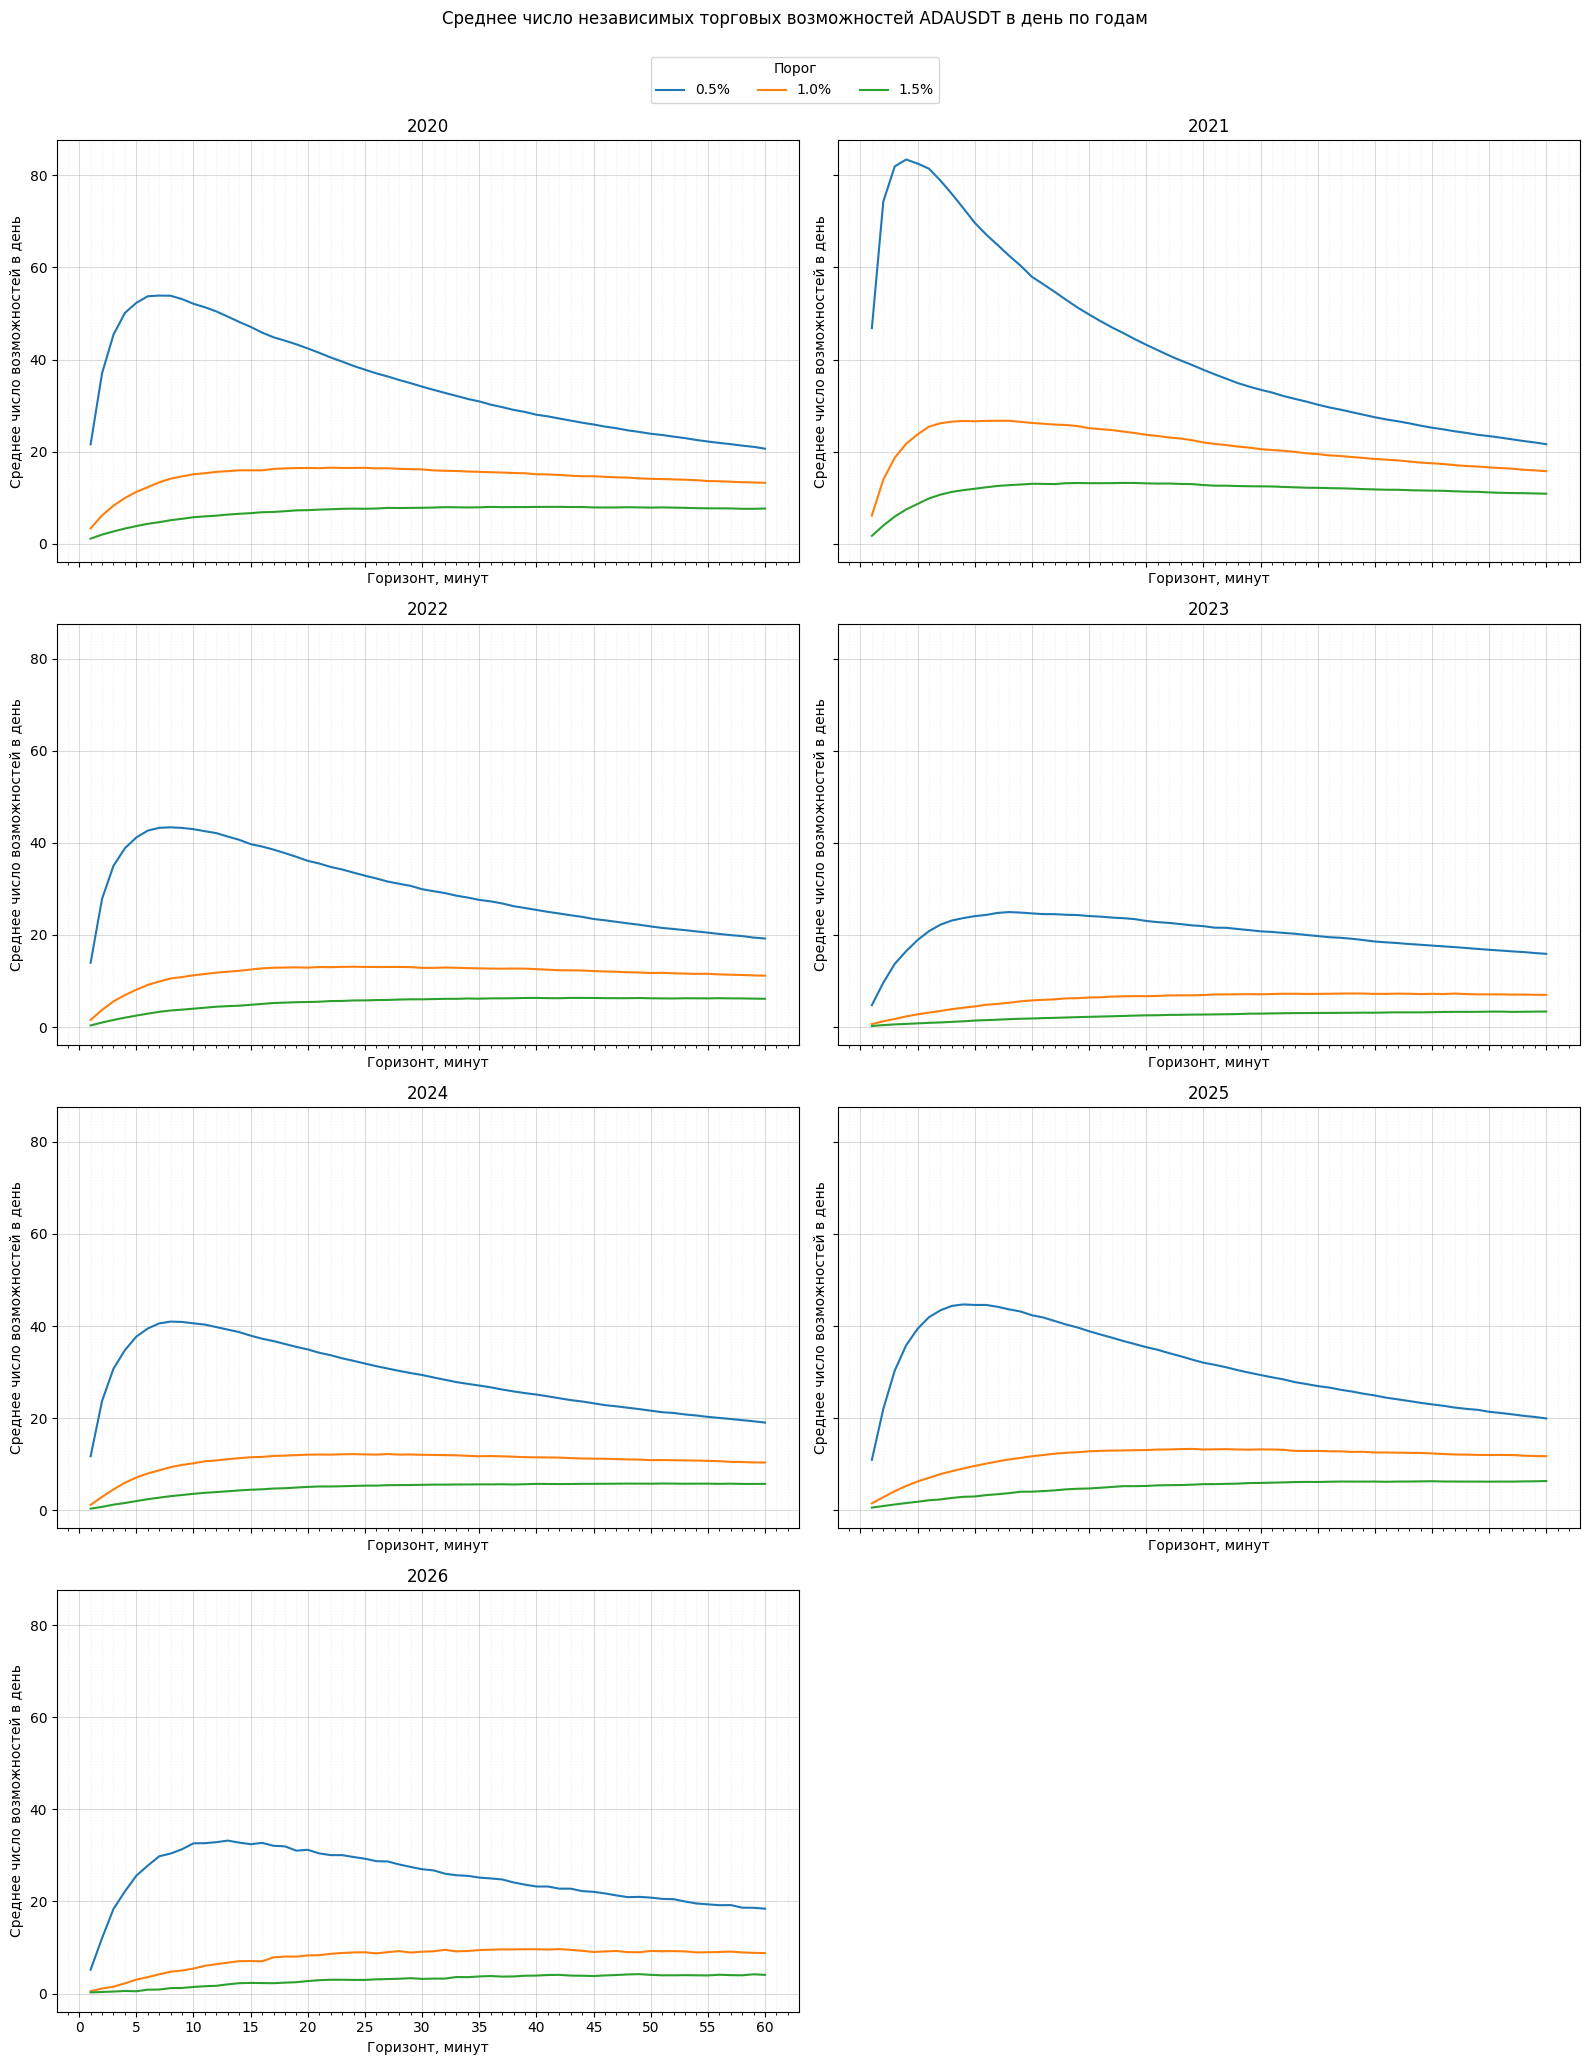

In [8]:
def build_opportunity_statistics_by_year(
    returns_df: pd.DataFrame,
    horizons: list[int] = HORIZONS,
    thresholds: list[float] = THRESHOLDS,
) -> pd.DataFrame:
    df = returns_df.copy()
    df["year"] = pd.to_datetime(df["open_time"], unit="ms", utc=True).dt.year

    rows = []

    for year, year_df in df.groupby("year"):
        number_of_calendar_days = (
            pd.to_datetime(year_df["open_time"], unit="ms", utc=True)
            .dt.date
            .nunique()
        )

        for threshold in thresholds:
            for horizon in horizons:
                valid_series = build_valid_future_return_series(
                    returns_df,
                    horizon,
                )

                year_mask = df["year"] == year
                year_series = valid_series.loc[year_mask].reset_index(drop=True)

                total_events = count_non_overlapping_events(
                    year_series,
                    horizon,
                    threshold,
                )

                rows.append(
                    {
                        "year": year,
                        "horizon": horizon,
                        "threshold": threshold,
                        "total_events": total_events,
                        "events_per_day": total_events / number_of_calendar_days,
                    }
                )

    return (
        pd.DataFrame(rows)
        .sort_values(["year", "threshold", "horizon"])
        .reset_index(drop=True)
    )


def plot_opportunity_statistics_by_year(
    opportunity_by_year_df: pd.DataFrame,
    save_path: str | None = None,
):
    years = sorted(opportunity_by_year_df["year"].unique())

    n_cols = 2
    n_rows = int(np.ceil(len(years) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.array(axes).reshape(-1)

    threshold_labels = {
        0.005: "0.5%",
        0.01: "1.0%",
        0.015: "1.5%",
    }

    for ax, year in zip(axes, years):
        year_df = opportunity_by_year_df[
            opportunity_by_year_df["year"] == year
        ]

        for threshold in THRESHOLDS:
            subset = year_df[year_df["threshold"] == threshold]

            ax.plot(
                subset["horizon"],
                subset["events_per_day"],
                label=threshold_labels[threshold],
            )

        ax.set_title(str(year))
        ax.set_xlabel("Горизонт, минут")
        ax.set_ylabel("Среднее число возможностей в день")

        ax.xaxis.set_major_locator(MultipleLocator(5))
        ax.xaxis.set_minor_locator(MultipleLocator(1))

        ax.grid(True, which="major", alpha=0.45)
        ax.grid(True, which="minor", alpha=0.2, linestyle=":")

    for ax in axes[len(years):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Порог",
        loc="upper center",
        ncol=len(THRESHOLDS),
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        "Среднее число независимых торговых возможностей ADAUSDT в день по годам",
        y=1.03,
    )
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, axes


opportunity_statistics_by_year = build_opportunity_statistics_by_year(
    future_returns_df
)

display(opportunity_statistics_by_year.head())
display(opportunity_statistics_by_year.tail())

fig, axes = plot_opportunity_statistics_by_year(
    opportunity_statistics_by_year
)
plt.show()